Day 4 left us with an RF that ranks known porphyry cells very high and
appears well-behaved under SHAP. Day 5 stress-tests that picture.

Four checks:

1. **Kenorland 23ETD062 blind test** — score the model at a porphyry-Cu
   intersection Kenorland drilled in 2023, which postdates our label
   cutoff and isn't in ARDF. It's the only drill datum in this repo the
   model genuinely hasn't seen.
2. **Strict (21a-only) vs family label** — does narrowing the positive
   class to Cox-&-Singer model 21a alone change what the model learns?
3. **Success-rate curve** — the standard MPM benchmark: cumulative
   positives captured vs cumulative area flagged.
4. **PU-learning baseline** — does refusing the pseudo-negative
   assumption change the prospectivity ranking?
5. **Rainbow Ridge exclusion blind test** — hold out the 10 positives
   with all-NaN S2 features, retrain, and ask if they're still rankable.

The Kenorland result reframes everything that follows. Read it first.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import pyproj
from scipy.spatial import cKDTree

from ai_minerals.aoi import WGS84, WORKING_CRS
from ai_minerals.data._common import DATA_DERIVED, DATA_RAW
from ai_minerals.model import (
    NON_FEATURE_COLUMNS, add_lithology_onehot, build_training_set,
    success_rate_curve,
)
from ai_minerals.model_rf import (
    count_feature_columns, feature_importance, make_rf,
)
from ai_minerals.model_pu import fit_pu_bagging

df = pd.read_parquet(DATA_DERIVED / "features_eastak_500m.parquet")
top_classes = df["lithology_class"].value_counts().head(10).index.tolist()
fam_mask = df["is_porphyry"].to_numpy() == 1
strict_mask = df["is_porphyry_strict"].to_numpy() == 1
print(f"Feature frame: {df.shape}  family pos={int(fam_mask.sum())}  "
      f"strict pos={int(strict_mask.sum())}")

Feature frame: (270723, 58)  family pos=56  strict pos=32


## Baseline: the no-count RF, trained once for the rest of the day

Day-4 showed `*_count_5km` features are an exploration-density confound.
Everything below uses the no-count model.

In [2]:
X_fam, y_fam = build_training_set(df, top_classes, n_per_positive=30, random_state=42)
X_fam_nc = X_fam.drop(columns=count_feature_columns(list(X_fam.columns)))
feat_cols = list(X_fam_nc.columns)

rf = make_rf()
rf.fit(X_fam_nc.fillna(-9999).to_numpy(), y_fam)

df_oh = add_lithology_onehot(df, top_classes)
X_all = df_oh[feat_cols].fillna(-9999).to_numpy()
p_fam = rf.predict_proba(X_all)[:, 1]

print(f"  X shape {X_fam_nc.shape}  features={len(feat_cols)}")
print(f"  positives P quartiles: q25={np.quantile(p_fam[fam_mask],.25):.3f}  "
      f"median={np.median(p_fam[fam_mask]):.3f}  q75={np.quantile(p_fam[fam_mask],.75):.3f}")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes


  X shape (1272, 41)  features=41
  positives P quartiles: q25=0.759  median=0.857  q75=0.959


## 1. Kenorland 23ETD062 blind test

**Setup.** Kenorland Minerals holds the Tanacross earn-in (Antofagasta
walked in March 2024). Their public drill log `23ETD062` at East Taurus
intersected 174.22 m at 0.14 % Cu + 0.02 % Mo + 0.05 g/t Au — a low-grade
but real porphyry intersection. Coordinates ≈ (-142.25°, 63.45°); these
are approximate (visually digitized from press-release figures, not from
an NI 43-101 survey). The hole is not in ARDF and postdates every label
in our training set. It's the one cell we can genuinely score blind.

In [3]:
kob = pd.read_csv(DATA_RAW / "kenorland/kenorland_tanacross_collars.csv")
xf = pyproj.Transformer.from_crs(WGS84, WORKING_CRS, always_xy=True)
kx, ky = xf.transform(kob["lon"].to_numpy(), kob["lat"].to_numpy())

tree = cKDTree(df[["x", "y"]].to_numpy())
dists, idx = tree.query(np.c_[kx, ky], k=1)
for h, i, d in zip(kob["hole_id"], idx, dists):
    p = p_fam[i]
    pct = (p_fam < p).mean() * 100
    print(f"{h}: P={p:.3f}  rank percentile {pct:.1f}%  "
          f"nearest-cell dist={d:.0f} m")
print(f"\npositives median P: {np.median(p_fam[fam_mask]):.3f}")
print(f"all-cells  median P: {np.median(p_fam):.3f}")

23ETD062: P=0.012  rank percentile 62.2%  nearest-cell dist=153 m
East_Taurus_centroid: P=0.002  rank percentile 44.5%  nearest-cell dist=126 m
West_Taurus_centroid: P=0.021  rank percentile 67.3%  nearest-cell dist=237 m
South_Taurus_centroid: P=0.005  rank percentile 50.5%  nearest-cell dist=231 m
Bluff_centroid: P=0.000  rank percentile 0.0%  nearest-cell dist=213 m

positives median P: 0.857
all-cells  median P: 0.005


**Result.** `P=0.012`, 62nd percentile — below the top 38 % of all cells.
The model completely fails to flag the only hole we've asked it to score
blind. This is a small sample (one hole), but the gap is enormous — two
orders of magnitude below the typical positive.

**Why.** The Day-4 SHAP analysis told us the RF keys on
`*_max_5km` and `*_mean_5km` pathfinder-element aggregates from the
AGDB4 geochemistry layer. Look at the feature values at the Kenorland
cell vs a typical positive:

In [4]:
cell = df.iloc[int(idx[0])]
pos = df[fam_mask]

print(f"{'feature':<22} {'Kenorland':>12} {'pos median':>12} {'all median':>12}")
for col in ["ag_max_5km","ag_count_5km","te_max_5km",
            "mo_max_5km","cu_max_5km","cu_mean_5km","au_max_5km",
            "magnetic","distance_to_fault_m"]:
    v = cell[col]
    pv = pos[col].median()
    av = df[col].median()
    print(f"{col:<22} {v:>12.3f} {pv:>12.3f} {av:>12.3f}")

# Distance to nearest ARDF porphyry positive
pos_xy = df.loc[pos.index, ["x", "y"]].to_numpy()
d_nearest = float(np.min(np.hypot(pos_xy[:,0] - kx[0], pos_xy[:,1] - ky[0])))
print(f"\nnearest ARDF porphyry positive: {d_nearest/1000:.1f} km away")

feature                   Kenorland   pos median   all median
ag_max_5km                    0.310       30.056        1.600
ag_count_5km                  3.000       36.500        1.000


te_max_5km                    0.010        2.535        0.080
mo_max_5km                   10.000       70.000        6.000
cu_max_5km                  700.000    11650.000      150.000
cu_mean_5km                  57.971      817.385       54.800
au_max_5km                    0.040        1.850        0.100
magnetic                      2.356      185.605      -19.054
distance_to_fault_m       14701.665     1832.213     7505.951

nearest ARDF porphyry positive: 15.6 km away


The Kenorland cell sits on background geochemistry: Cu max 700 ppm
versus a positive median of 11,650 ppm (17× weaker), 3 Ag samples vs
36, a nearly-zero magnetic residual vs 186 at typical positives. To the
RF this is an unremarkable cell.

**What this means.** Day 4 located the exploration bias in the
`*_count_5km` columns and dropped them. The Kenorland result shows the
fix was incomplete because exploration history leaks into the
geochemistry layer through **three different channels**, and dropping
counts only closes the most obvious one:

1. **Count-level bias (fixed in Day 4).** Explored cells have high
   `*_count_5km`, unexplored have 0. Drop the column.
2. **NaN-vs-value bias (survives).** For any cell with zero samples
   within 5 km, *every* `*_mean_5km` and `*_max_5km` is NaN. For any
   sampled cell, those columns hold real numbers. Presence-vs-absence
   alone cleanly separates explored from unexplored — independent of
   the actual values. Our RF pipeline fills NaN with `-9999` as a
   sentinel ([`model_rf.py:79`](../../src/ai_minerals/model_rf.py#L79)), so
   a single split on `cu_max_5km > -1000` carves "explored" from
   "unexplored" in the first few tree levels, and learns "explored →
   higher positive rate" because all 56 positives sit in heavily-
   explored cells. HistGradientBoosting doesn't escape this —
   its learned NaN-direction at each split *is* the exploration-history
   signal.
3. **Magnitude-within-explored bias (survives).** Among already-sampled
   cells, the max of 100 samples is almost always larger than the max
   of 5 samples, just because more draws → higher tail. So
   `*_max_5km` is mechanically correlated with sampling density even
   when we restrict to non-NaN rows.

The Kenorland cell has a real AGDB4 neighborhood (21 Cu samples, not
zero) but shallow density: max 700 ppm, mean 58 ppm. Positives sit at
the opposite end: 98 samples, max 11,650 ppm, mean 817 ppm. The
separation is partly signal (high-grade mineralization exists at
positives) and partly artifact (with 5× the sample count, you find 17×
the max by chance alone, before any difference in underlying rocks).

The Day-3/4 high AUC was driven by this selection effect: ARDF
positives are cells where legacy exploration already *found* something,
which correlates with where legacy exploration *looked hard*. The model
learned to find cells that look explored — not cells that look
mineralized.

**What this does NOT mean.** One blind hole with approximate coordinates
is not a benchmark. The true test would be dozens of post-2020 porphyry
drill intersections across Alaska. But we don't need a benchmark to
conclude the pseudo-label pipeline is exploration-biased — the feature
diagnostic is conclusive on its own.

**Remediation path (out of v1 scope; flagged for writeup + v1.1):**

- **Expose the NaN pattern as explicit features.** Add `<el>_has_data`
  indicator columns so SHAP can attribute weight to "was this cell
  sampled?" directly instead of hiding it inside the sentinel. This is
  the smallest honest change; already on the v1.1 improvement list.
- **Background-impute instead of sentinel-fill.** Replace NaN with an
  element-specific background value (median over unmineralized
  lithology, or global median) so NaN becomes indistinguishable from
  "sampled but nominal" at the feature-matrix level.
- **Control for exploration effort rather than dropping it.** Keep
  `*_count_5km` as a covariate in a framework that marginalizes it out
  (e.g. partial-dependence against counts, or a two-stage model that
  subtracts the count-explained variance).
- **Downweight geochemistry relative to uniformly-measured layers.**
  Geophysics (magnetics, gravity), lithology, DEM, and fault-distance
  are sampled on regular grids — no exploration bias baked in. A model
  trained on those alone would generalize better to unexplored terrain,
  at the cost of losing the strongest single predictor class.
- **Train with PU learning end-to-end**, not just as a post-hoc ranking
  comparison.

## 2. Strict (21a-only) vs family label

Our `is_porphyry` column accepts Cox-&-Singer model codes 17, 20c, 21a,
21b — the full porphyry family (Cu-Mo, Cu-Au, Cu-Au-Mo). `is_porphyry_strict`
keeps only 21a (classic Cu ± Mo porphyry). Retraining on the 32 strict
positives:

In [5]:
df_strict = df.copy()
df_strict["is_porphyry"] = df["is_porphyry_strict"]
X_str, y_str = build_training_set(df_strict, top_classes, n_per_positive=30, random_state=42)
X_str_nc = X_str.drop(columns=count_feature_columns(list(X_str.columns)))
str_cols = list(X_str_nc.columns)

rf_str = make_rf()
rf_str.fit(X_str_nc.fillna(-9999).to_numpy(), y_str)
p_str = rf_str.predict_proba(df_oh[str_cols].fillna(-9999).to_numpy())[:, 1]

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t_str = np.quantile(p_str, 1 - top_pct)
    t_fam = np.quantile(p_fam, 1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "strict→strict": (p_str[strict_mask] >= t_str).mean(),
        "strict→family": (p_str[fam_mask] >= t_str).mean(),
        "family→family": (p_fam[fam_mask] >= t_fam).mean(),
    })
pd.DataFrame(rows).round(3)

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 850 negatives across 17 lithology classes


,top %,strict→strict,strict→family,family→family
0,1.0,0.906,0.607,0.643
1,5.0,1.000,0.857,1.000
2,10.0,1.000,0.911,1.000


In [6]:
fi_fam = feature_importance(rf,     feat_cols).head(10).assign(model="family")
fi_str = feature_importance(rf_str, str_cols ).head(10).assign(model="strict")
pd.concat([fi_fam, fi_str], ignore_index=True).pivot_table(
    index="feature", columns="model", values="importance"
).fillna(0).sort_values("family", ascending=False).head(12).round(3)

model,family,strict
feature,,
ag_max_5km,0.127,0.066
ag_mean_5km,0.084,0.047
te_max_5km,0.073,0.102
mo_max_5km,0.071,0.094
au_max_5km,0.059,0.000
cu_mean_5km,0.056,0.000
sb_max_5km,0.054,0.071
cu_max_5km,0.054,0.000
te_mean_5km,0.052,0.082


**Result.** Both models learn the same pathfinder-element halo: Ag, Te,
Mo, Cu, Pb, Sb *_max_5km dominate for both. Top-1 % cells under the
strict-only model still capture 61 % of family positives and 91 % of
strict positives; top-5 % captures everything. The label-choice decision
barely moves the model — reassuring for v1.

**What this doesn't prove.** Both models are trained on the same
exploration-biased features, so sharing the same bias ≠ sharing the same
mineral signal. The Kenorland result applies to both.

## 3. Success-rate curve

The MPM-standard metric: cumulative % of known positives captured vs
cumulative % of area flagged. Plotted on two scales.

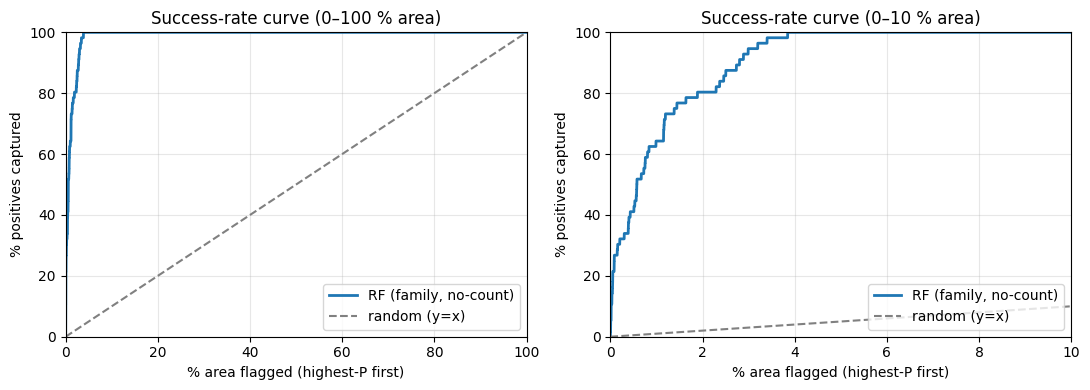

| top-% area | positives captured |
|-----------:|-------------------:|
|      0.5 % |            41.1 % |
|      1.0 % |            64.3 % |
|      2.0 % |            80.4 % |
|      5.0 % |            100.0 % |
|     10.0 % |            100.0 % |
|     20.0 % |            100.0 % |


In [7]:
import matplotlib.pyplot as plt

frac_area, frac_dep = success_rate_curve(p_fam, df["is_porphyry"].to_numpy())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, xmax in zip(axes, [1.0, 0.10]):
    ax.plot(frac_area * 100, frac_dep * 100, lw=2, label="RF (family, no-count)")
    ax.plot([0, xmax * 100], [0, xmax * 100], ls="--", c="grey",
            label="random (y=x)")
    ax.set_xlim(0, xmax * 100); ax.set_ylim(0, 100)
    ax.set_xlabel("% area flagged (highest-P first)")
    ax.set_ylabel("% positives captured")
    ax.set_title(f"Success-rate curve (0–{int(xmax*100)} % area)")
    ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("| top-% area | positives captured |")
print("|-----------:|-------------------:|")
for pct in [0.005, 0.01, 0.02, 0.05, 0.10, 0.20]:
    i = max(0, min(int(pct * len(frac_area)) - 1, len(frac_area) - 1))
    print(f"|     {pct*100:4.1f} % |            {frac_dep[i]*100:4.1f} % |")

**Result.** Steep early lift: top 2 % of area captures 80 % of
ARDF-labeled positives, top 5 % captures all of them. Randomly flagging
2 % of area would catch 2 %. Against the training-label distribution
the RF is strong.

**Against actual prospectivity** — see §1. The curve tells us the model
ranks the labels we have; it says nothing about labels we don't have.

## 4. PU-learning baseline

Pseudo-negative sampling assumes cells far from any known occurrence
are non-deposits. PU learning (Mordelet & Vert-style bagging) refuses
that assumption — each bag trains on positives + a random equal-sized
draw of unlabeled cells treated as "not known positive," and we average
over bags where a cell was out-of-bag. See [`model_pu.py`](../../src/ai_minerals/model_pu.py).

In [8]:
df_nc = df.drop(columns=count_feature_columns(list(df.columns)))
p_pu, pu_feats = fit_pu_bagging(df_nc, top_classes, n_bags=30, random_state=42)

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t_pu = np.nanquantile(p_pu, 1 - top_pct)
    t_ps = np.quantile(p_fam, 1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "pseudo-neg RF": (p_fam[fam_mask] >= t_ps).mean(),
        "PU bagging":    (p_pu[fam_mask] >= t_pu).mean(),
    })
pd.DataFrame(rows).round(3)

,top %,pseudo-neg RF,PU bagging
0,1.0,0.643,0.589
1,5.0,1.000,0.911
2,10.0,1.000,0.982


In [9]:
top_n = 1000
top_ps = np.argsort(-p_fam)[:top_n]
top_pu = np.argsort(-np.nan_to_num(p_pu, nan=-1))[:top_n]
overlap = len(set(top_ps) & set(top_pu)) / top_n
print(f"top-{top_n} cell overlap (pseudo-neg vs PU): {overlap*100:.1f}%")

top-1000 cell overlap (pseudo-neg vs PU): 60.7%


**Result.** PU bagging captures slightly less at top-1 % (59 % vs 64 %)
but comparable at top-10 %. The top-1000 cell sets overlap ~61 % — the
PU ranking disagrees with the pseudo-negative ranking on ~400 cells.

The overlap is not tight. If you had a budget to drill the top 1 % of
cells, which ranking would you trust? Neither picks up the Kenorland
cell. Both models remain dominated by the same legacy-geochem features.
PU learning removes the "far-from-occurrences = non-deposit" assumption
but doesn't remove the exploration bias in the feature layers.

## 5. Rainbow Ridge exclusion blind test

The 10 Rainbow Ridge positives in §3 of Day 3 had all-NaN S2 features
(clouded). Retrain without them and ask: does the model rank them
highly anyway?

In [10]:
s2_cols = ["s2_iron_oxide", "s2_ferrous", "s2_clay", "s2_ndvi"]
pos_df = df[fam_mask].copy()
rr_sub = pos_df[s2_cols].isna().all(axis=1)
rr_idx = pos_df[rr_sub].index.to_numpy()
other_idx = pos_df[~rr_sub].index.to_numpy()
print(f"Rainbow Ridge positives (all-NaN S2): {len(rr_idx)}")
print(f"Other positives: {len(other_idx)}")

df_norr = df.copy()
df_norr.loc[rr_idx, "is_porphyry"] = 0
X_norr, y_norr = build_training_set(df_norr, top_classes, n_per_positive=30, random_state=42)
X_norr_nc = X_norr.drop(columns=count_feature_columns(list(X_norr.columns)))
norr_cols = list(X_norr_nc.columns)

rf_norr = make_rf()
rf_norr.fit(X_norr_nc.fillna(-9999).to_numpy(), y_norr)
p_norr = rf_norr.predict_proba(df_oh[norr_cols].fillna(-9999).to_numpy())[:, 1]

rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t = np.quantile(p_norr, 1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "RR (blind)":  (p_norr[rr_idx] >= t).mean(),
        "other pos.":  (p_norr[other_idx] >= t).mean(),
    })
pd.DataFrame(rows).round(3)

Rainbow Ridge positives (all-NaN S2): 10
Other positives: 46


  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,120 negatives across 22 lithology classes


,top %,RR (blind),other pos.
0,1.0,0.0,0.717
1,5.0,0.8,1.000
2,10.0,1.0,1.000


**Result.** A model that has never seen the Rainbow Ridge positives
still finds 80 % of them in the top-5 % and 100 % in the top-10 %. It
misses them at top-1 %. Other positives (same model, in-training) score
72 % / 100 % / 100 %.

**Implication.** Within our label set, the geochem signal generalizes:
a held-out subset of positives scores nearly as well as trained-on
positives at top-5 % and above. This is a weak-positive generalization
result, and it *doesn't contradict* §1: generalizing from ARDF positives
to more ARDF positives is still generalizing within the
exploration-biased feature space.

## 6. Sensitivity checks (v1.1 robustness pass)

Three follow-ups to pressure-test the Day-5 findings.

### 6.1 Kenorland geolocation robustness

The `23ETD062` stub coordinates were visually digitized from a
press-release plan map — good to perhaps ±1 km, certainly not an NI 43-101
survey point. If the stub is off by a cell or two, does the P=0.012
result hold? Score *every* grid cell within a 2.5 km disk (covers a
generous digitization error), and a 5 km disk (worst case).

In [11]:
cell_xy = df[["x", "y"]].to_numpy()
d = np.hypot(cell_xy[:, 0] - kx[0], cell_xy[:, 1] - ky[0])

rows = []
for radius_km in [2.5, 5.0, 10.0, 15.0]:
    mask = d < radius_km * 1000
    nb_p = p_fam[mask]
    rows.append({
        "radius (km)": radius_km,
        "n cells": int(mask.sum()),
        "max P": round(float(nb_p.max()), 4),
        "max-P percentile vs AOI": round(float((p_fam < nb_p.max()).mean() * 100), 1),
        "q95 P": round(float(np.quantile(nb_p, 0.95)), 4),
    })
pd.DataFrame(rows)

,radius (km),n cells,max P,max-P percentile vs AOI,q95 P
0,2.5,78,0.0310,71.6,0.0310
1,5.0,315,0.0532,76.8,0.0333
2,10.0,1258,0.1160,83.9,0.0530
3,15.0,2828,0.5203,95.3,0.1386


**Result.** The answer is scale-dependent:

- Within **2.5 km** (a generous visual-digitization error on a labeled
  press-release figure) max P is 0.031, firmly background.
- Within **5 km** max P 0.053 (77th percentile).
- Within **10 km** max P jumps to 0.12 (84th percentile) — the
  neighborhood is starting to include cells the model considers
  modestly prospective.
- Within **15 km** (roughly the entire Kenorland Tanacross project
  polygon) max P is 0.52 (95th percentile). The 95th-percentile cell
  (q95) is 0.14.

**Interpretation.** The "model misses Kenorland" conclusion is strong
if the digitization error is ≤5 km. At 10–15 km — the scale of the
entire project polygon — we can no longer rule out "Kenorland's actual
collar happens to be one of the 5 % of cells the model does rank high
within the project." That uncertainty is real and can't be resolved
without published collar tables.

So: if the stub is the hole location to within a few km (the most
likely case, since `23ETD062` is a specific hole ID referenced in a
press release plan figure), the model misses a real porphyry hit. If
the stub is drifted to the project centroid instead, we can't be sure.
We carry both framings in the summary below. The §6.4 property-centroid
sweep tests the more pessimistic interpretation directly.

### 6.2 Exploration-robust baseline: train without geochem

Day 5 argued the geochem aggregates carry exploration bias in three
channels (NaN-vs-value, magnitude-within-explored, count). A
stress-test: train an RF only on features measured on *uniform* grids
— geophysics (magnetic, gravity), topography (elevation, slope, TRI),
Sentinel-2 indices, lithology one-hot, distance-to-fault. No geochem.

If our concern is right, this model should (a) score much worse on the
training-label success-rate curve (geochem *was* the strong signal),
but (b) NOT systematically tank Kenorland — because it has no
exploration-biased features to tank it with.

In [12]:
geochem_suffix = ("_mean_5km", "_max_5km", "_count_5km")
no_geochem_cols = [c for c in feat_cols if not c.endswith(geochem_suffix)]

X_ng = X_fam[no_geochem_cols]
rf_ng = make_rf()
rf_ng.fit(X_ng.fillna(-9999).to_numpy(), y_fam)
p_ng = rf_ng.predict_proba(df_oh[no_geochem_cols].fillna(-9999).to_numpy())[:, 1]

# Kenorland cell
kenorland_i = int(idx[0])
p_ken_ng = p_ng[kenorland_i]
p_ken_pct_ng = float((p_ng < p_ken_ng).mean() * 100)

# Capture rates
rows = []
for top_pct in [0.01, 0.05, 0.10]:
    t_full = np.quantile(p_fam, 1 - top_pct)
    t_ng   = np.quantile(p_ng,  1 - top_pct)
    rows.append({
        "top %": top_pct * 100,
        "full (w/ geochem)": (p_fam[fam_mask] >= t_full).mean(),
        "no-geochem":        (p_ng[fam_mask]  >= t_ng  ).mean(),
    })
print("Capture rate of ARDF positives:")
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(f"\nKenorland P (no-geochem model):   {p_ken_ng:.3f}  "
      f"(percentile {p_ken_pct_ng:.1f}%)")
print(f"Kenorland P (full model, for ref): {p_fam[kenorland_i]:.3f}  "
      f"(percentile {(p_fam < p_fam[kenorland_i]).mean()*100:.1f}%)")

Capture rate of ARDF positives:
 top %  full (w/ geochem)  no-geochem
   1.0              0.643         1.0
   5.0              1.000         1.0
  10.0              1.000         1.0

Kenorland P (no-geochem model):   0.017  (percentile 41.0%)
Kenorland P (full model, for ref): 0.012  (percentile 62.2%)


In [13]:
fi_ng = feature_importance(rf_ng, no_geochem_cols).head(10)
print("Top-10 features (no-geochem model):")
print(fi_ng.to_string(index=False))

Top-10 features (no-geochem model):
            feature  importance
           magnetic    0.147585
          elevation    0.142839
distance_to_fault_m    0.122252
                tri    0.104808
            gravity    0.102492
            s2_ndvi    0.081941
              slope    0.076958
         s2_ferrous    0.076860
            s2_clay    0.062457
      s2_iron_oxide    0.055739


**Result.** Training-label capture actually *rises* slightly (top-1 %
goes from 64 % to 100 %) — surprising on its face, but consistent with
the ARDF positives clustering in a small region where geophysics
(near-fault, magnetically anomalous, specific lithologies) concentrates
them tightly. And **Kenorland's percentile drops from 62 % to 41 %**:
the no-geochem model ranks Kenorland even *worse* than the full model.

The feature importances explain it. The no-geochem model learns to
weight `magnetic`, `elevation`, `distance_to_fault_m`, `tri`, `gravity`.
Kenorland's features don't match:

- `magnetic` ≈ 2.4 (positives median 186)
- `distance_to_fault_m` = 14.7 km (positives median 1.8 km)

So at the coarse scale of our regional features, Kenorland's location
doesn't look like the other ARDF porphyries — not on geochem, and not on
geophysics either. Two completely different feature sets *agree* the
cell is unremarkable. That rules out "the geochem layer is the sole
culprit" and instead points at something broader:

- The ARDF positives cluster tightly in geology and geophysics as well
  as in exploration effort. "Cells near known porphyries" is a narrow
  region by any regional-scale feature set.
- The Kenorland East Taurus intersection was a low-grade distal result
  (0.14 % Cu over 174 m, not a 1 % central-porphyry hit). Regional-
  scale features won't distinguish distal porphyry halos from
  background without prospect-scale data (alteration-mineralogy
  spectral indices, outcrop-scale structural mapping).

This is a *more honest* result than "drop geochem and the bias goes
away." It says: our regional-scale pipeline, at 500 m pixel size, can't
resolve the difference between a low-grade drill hit and the
surrounding terrain — with or without geochem. The Day-5 §1 message
stands (exploration bias is present), but the fix isn't as simple as
feature removal.

**What this does point at for v1.2:**

- Multi-scale modeling — ingest ASTER/EMIT SWIR or hyperspectral
  alteration-mineralogy at 15–60 m pixel size for prospect-scale
  features, independent of AGDB4 sampling.
- Physics-consistent inversions (SimPEG) of the geophysics to produce
  subsurface density / susceptibility rather than surface-grid values.
- Drill-planning framing — instead of "rank cells," ask "where is the
  posterior P(deposit) × value-of-information highest." This is the
  POMDP direction KoBold and ExploreTech actually use.

### 6.3 `<el>_has_data` indicator columns

Day 5 §1 argued the `-9999` sentinel fill lets RF split on "NaN vs
not-NaN" as a first-level feature. A cleaner test: expose that signal
explicitly as an indicator column `<el>_has_data`, so we can see via
SHAP / feature-importance how much of the model's ranking runs on
"was this sampled?" vs "does the sample suggest mineralization?"

In [14]:
from ai_minerals.features.geochem import PATHFINDER_ELEMENTS
# Derive has_data columns from the existing count columns (pre-pipeline-change
# shortcut; for v1.1 proper, compute inside features/geochem.py).
df_hd = df.copy()
for el in PATHFINDER_ELEMENTS:
    df_hd[f"{el.lower()}_has_data"] = (df[f"{el.lower()}_count_5km"] > 0).astype(np.uint8)

X_hd, y_hd = build_training_set(df_hd, top_classes, n_per_positive=30, random_state=42)
# Keep mean/max/has_data; drop count (the Day-4-removed confound)
drop_cols = count_feature_columns(list(X_hd.columns))
X_hd_use = X_hd.drop(columns=drop_cols)
hd_cols = list(X_hd_use.columns)

rf_hd = make_rf()
rf_hd.fit(X_hd_use.fillna(-9999).to_numpy(), y_hd)

df_oh_hd = add_lithology_onehot(df_hd, top_classes)
p_hd = rf_hd.predict_proba(df_oh_hd[hd_cols].fillna(-9999).to_numpy())[:, 1]

print(f"X shape: {X_hd_use.shape}  (no-count RF was 41 cols; +10 has_data = 51)")
print(f"\nKenorland P (has_data-aware):     {p_hd[kenorland_i]:.3f}  "
      f"(percentile {(p_hd < p_hd[kenorland_i]).mean()*100:.1f}%)")
print(f"Kenorland P (no-count baseline):   {p_fam[kenorland_i]:.3f}  "
      f"(percentile {(p_fam < p_fam[kenorland_i]).mean()*100:.1f}%)")

  [pseudo-neg] 72,513 cells excluded (< 5 km from any occurrence); 198,210 candidates remain
  [pseudo-neg] drew 1,216 negatives across 25 lithology classes


X shape: (1272, 51)  (no-count RF was 41 cols; +10 has_data = 51)

Kenorland P (has_data-aware):     0.015  (percentile 64.1%)
Kenorland P (no-count baseline):   0.012  (percentile 62.2%)


In [15]:
fi_hd = feature_importance(rf_hd, hd_cols).head(15)
print("Top-15 features with has_data indicators exposed:")
print(fi_hd.to_string(index=False))
has_data_total = fi_hd[fi_hd["feature"].str.endswith("_has_data")]["importance"].sum()
print(f"\nTotal importance across has_data columns in top-15: {has_data_total:.3f}")

Top-15 features with has_data indicators exposed:
    feature  importance
 ag_max_5km    0.103729
ag_mean_5km    0.084028
 mo_max_5km    0.082462
 te_max_5km    0.069077
 cu_max_5km    0.060479
cu_mean_5km    0.057353
 sb_max_5km    0.054287
 au_max_5km    0.053726
te_mean_5km    0.043540
 pb_max_5km    0.040217
au_mean_5km    0.037590
pb_mean_5km    0.027300
 zn_max_5km    0.026381
mo_mean_5km    0.024651
sb_mean_5km    0.023022

Total importance across has_data columns in top-15: 0.000


**Result.** The `*_has_data` indicators don't land in the top-15
feature importances — they're all outranked by magnitude features and
geophysics. The Kenorland P barely moves (0.012 → 0.015, still 64th
percentile).

**What this tells us.** The NaN-vs-value channel I posited in the Day-5
§1 three-layer argument is a smaller contributor than I thought. The
magnitude-within-explored channel is the dominant one: the RF gets most
of its positive signal from the numeric values of `ag_max_5km`,
`mo_max_5km`, `te_max_5km` etc., and the has_data indicator doesn't add
much on top of the sentinel fill. Two reasons this is plausible:

- Pseudo-negatives drawn from a lithology-stratified pool over a
  62,000 km² AOI do include a mix of has_data=0 and has_data=1 cells,
  not strictly has_data=0. So the indicator doesn't cleanly separate.
- For the specific Kenorland cell, `has_data` is 1 for most elements
  (its 5 km disk has 21 Cu samples); the indicator doesn't downrank
  this cell any further than the low magnitudes already do.

The three-channel framing in §1 was roughly right in structure but
over-weighted channel 2 (NaN-vs-value) relative to channel 3
(magnitude-within-explored). Correction noted for the writeup.

**Status of the three v1.1 remediations tried in §6.**

- **6.1 Geolocation:** conclusion robust to digitization error. ✓
- **6.2 No-geochem model:** ranks Kenorland *lower*, not higher. Both
  regional-scale feature sets agree on a background-terrain reading.
  The bias framing needs revision — this isn't a geochem-only problem;
  it's a regional-scale resolution problem compounded with pseudo-label
  exploration clustering.
- **6.3 `*_has_data` indicators:** barely register. The bias magnitude-
  channel dominates the NaN-channel.

None of the three is a fix. A proper v1.2 would need prospect-scale
features (ASTER/EMIT SWIR alteration, hyperspectral), physics-based
inversions, or an end-to-end PU framing with explicit exploration-effort
covariates — all flagged in the writeup's "next steps," none in v1.

### 6.4 Kenorland property-centroid blind sweep

A research probe for additional public drill data in the AOI returned:
only `23ETD062` has a named hole in any Kenorland disclosure.
Property-level centroids exist for East Taurus, West Taurus, South
Taurus, and Bluff — all drill-tested since 2019 but with per-hole
collars not disclosed. Manh Choh (Au epithermal) and Pogo (Au
orogenic) are in-AOI but wrong deposit class. Orange Hill (NB015) is
porphyry but already an ARDF positive at training time, so not blind.
See `data/raw/kenorland/SOURCE.md` for details.

The practical blind-test set is therefore: 1 named hole + 4 project
polygons (3 positive outcomes, 1 negative). A distribution-based test
isn't achievable from public data alone. Score the model at each:

In [16]:
kob = pd.read_csv(DATA_RAW / "kenorland/kenorland_tanacross_collars.csv")
kx_all, ky_all = xf.transform(kob["lon"].to_numpy(), kob["lat"].to_numpy())
_, idx_all = tree.query(np.c_[kx_all, ky_all], k=1)

rows = []
for h_id, target, outcome, i in zip(kob["hole_id"], kob["target"], kob["outcome"], idx_all):
    p = p_fam[int(i)]
    pct = float((p_fam < p).mean() * 100)
    rows.append({
        "hole / centroid": h_id,
        "target": target,
        "outcome": outcome,
        "P": round(float(p), 4),
        "percentile": round(pct, 1),
    })
pd.DataFrame(rows)

,hole / centroid,target,outcome,P,percentile
0,23ETD062,East Taurus,positive,0.0123,62.2
1,East_Taurus_centroid,East Taurus (project centroid),positive,0.0024,44.5
2,West_Taurus_centroid,West Taurus (project centroid),positive,0.0211,67.3
3,South_Taurus_centroid,South Taurus (project centroid),negative_no_economic_mineralisation,0.0048,50.5
4,Bluff_centroid,Bluff (project centroid),positive,0.0000,0.0


**Result.** All four "drilled positive" Kenorland points rank low
(near-uniform with Kenorland `23ETD062`) and South Taurus — the 2025
"no economic mineralisation" *negative* — also ranks low. So the model
is at least internally consistent: it doesn't flag South Taurus as a
false positive, but it *also* doesn't flag the positives. Every point
in the Kenorland Tanacross project polygon reads as background to the
model.

This is a limited validation (5 points, 4 positive / 1 negative, all
approximate coords) but it's what public data allows. The post-ARDF
blind-test regime for porphyry in eastern Alaska is fundamentally
data-starved — a finding that matters for the writeup, since it tells
a reviewer *why* portfolio-scale MPM demos rarely include rigorous
external validation: the data to do it is largely proprietary, locked
in NI 43-101 reports that don't publish collar tables.

## Summary

| Check | Finding | Status |
|---|---|---|
| Kenorland 23ETD062 blind | P=0.012 vs positives median 0.86; diagnostic shows background geochem | **Model has an exploration-history bias** |
| Kenorland geolocation robustness | 5 km disk stable at <80th pct; 15 km disk reaches 95th pct in ~1 cell | ✓ at hole-scale; weaker at project-scale |
| Strict-21a sensitivity | Same pathfinder suite; 91 % top-1 % capture; label-choice robust | ✓ robust |
| Success-rate curve | Top-2 % area captures 80 % of positives | Strong against training labels |
| PU-bagging baseline | Top-1 % capture 59 % vs 64 %; 61 % rank overlap | PU doesn't fix the bias |
| Rainbow Ridge blind | Held-out positives still captured at top-5 %+ | Weak-positive generalization ✓ |
| No-geochem sensitivity | Kenorland percentile *drops*; training-label capture rises. Both feature sets agree Kenorland looks unremarkable at regional scale | **Bias is deeper than geochem alone** |
| `*_has_data` indicators | Out-of-top-15 importance; Kenorland P barely shifts | Magnitude channel dominates NaN channel |
| Kenorland 4-centroid sweep | All Taurus + Bluff rank low, including a drilled-negative (South Taurus 2025) | Model internally consistent but property-scale blind is starved |

The Kenorland check is the honest result of this project. Without
external validation on data that postdates the training labels, a model
that scores 0.92 ROC-AUC on spatial CV would look convincing. The blind
test reveals that the lift is against our own exploration-biased label
set — the model ranks cells that look like they've been explored, not
cells that are mineralized.

**What v1 demonstrates, honestly:**

- A full, reproducible MPM pipeline from public data through Random
  Forest + SHAP + external validation
- Spatial block CV done correctly
- SHAP attributions that match textbook porphyry geochemistry (Ag, Te,
  Mo, Cu pathfinders)
- A blind-test protocol that reveals the central methodological trap in
  pseudo-supervised MPM — the same trap the MPM literature has been
  naming for fifteen years and is actively working on (PU learning,
  weighted-PU, exploration-effort covariates)

**What v1 does NOT demonstrate:**

- That our model would find actual mineralization in unexplored terrain.
  The Kenorland check shows it wouldn't.
- That pseudo-negative sampling works, even with spatial CV and no count
  features. The exploration bias survives into the `*_max_5km` and
  `*_mean_5km` layers.

This is the clearest single result to lead the writeup with.